# This is the complete pipeline for SpikeInterface Analysis for our datasets
**by adamfed0r**

It includes the following steps:
- importing libraries (np, mpl, pd, si and subfolders, probeinterface)
- creating a Recording object
- adding our own *spiky probe*
- creating a Sorting object from a KiloSort-ed and *phy* curated dataset
- creating a SortingAnalyzer
- computing various metrics
- opening the SpikeInterface GUI for visualization of the metrics and the Sorting Analyzer

## Importing libraries

In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import spikeinterface as si
%matplotlib widget
import spikeinterface.extractors as se
from spikeinterface.extractors import read_phy
import probeinterface as pi
from probeinterface import Probe
from probeinterface.plotting import plot_probe
from spikeinterface import create_sorting_analyzer, load_sorting_analyzer
from spikeinterface import preprocessing as pre
from spikeinterface import postprocessing as post
import spikeinterface.widgets as sw

## Dictionary to store all paths to data

In [4]:
# creating the names of the folders for the recording and sorting to be loaded from
# there's a list of the names and one can change the name of the loaded directory by changing the index of the list
data_folders = dict()
data_folders["SP9_01"] = "/Volumes/AFedor_T7/TTK-NeuroData/sp_9_20220215/spike_sorting_Thresh_9_9/Data/01"
data_folders["SP9_02"] = "/Volumes/AFedor_T7/TTK-NeuroData/sp_9_20220215/spike_sorting_Thresh_9_9/Data/02"
data_folders["SP9_03"] = "/Volumes/AFedor_T7/TTK-NeuroData/sp_9_20220215/spike_sorting_Thresh_9_9/Data/03"
data_folders["SP6_01"] = "/Volumes/AFedor_T7/TTK-NeuroData/sp_6_20180628/spike_sorting_Thresh_9_9/Data/01"
data_folders["SP6_02"] = "/Volumes/AFedor_T7/TTK-NeuroData/sp_6_20180628/spike_sorting_Thresh_9_9/Data/02"
data_folders["SP6_03"] = "/Volumes/AFedor_T7/TTK-NeuroData/sp_6_20180628/spike_sorting_Thresh_9_9/Data/03"
data_folders["SP6_04"] = "/Volumes/AFedor_T7/TTK-NeuroData/sp_6_20180628/spike_sorting_Thresh_9_9/Data/04"
data_folders["SP7_01"] = "/Volumes/AFedor_T7/TTK-NeuroData/sp_7_20190305/Spike Sorting/Data/01"
data_folders["SP7_02"] = "/Volumes/AFedor_T7/TTK-NeuroData/sp_7_20190305/Spike Sorting/Data/02"
data_folders["SP1_01"] = "/Volumes/AFedor_T7/TTK-NeuroData/sp_1_20171017/Spike Sorting/Data/01"
data_folders["SP1_02"] = "/Volumes/AFedor_T7/TTK-NeuroData/sp_1_20171017/Spike Sorting/Data/02"
data_folders["SP1_03"] = "/Volumes/AFedor_T7/TTK-NeuroData/sp_1_20171017/Spike Sorting/Data/03"
data_folders["SP1_04"] = "/Volumes/AFedor_T7/TTK-NeuroData/sp_1_20171017/Spike Sorting/Data/04"


## Recording Object

In [6]:
recording = se.BinaryRecordingExtractor(
    # the file can be changed by changing the index of the dictionary 
    # pay attention to the fact that the file name is correlated with the name of the folder, 
    # so if you change the folder, you should also change the file name
    file_paths=str(data_folders["SP9_01"] + "/01.dat"),  # the same file KiloSort used
    sampling_frequency=20000.0, # in Hz
    num_channels=32,
    dtype="int16" # KiloSort default;
)

print(recording)

BinaryRecordingExtractor: 32 channels - 20.0kHz - 1 segments - 3,599,280 samples 
                          179.96s (3.00 minutes) - int16 dtype - 219.68 MiB
  file_paths: ['/Volumes/AFedor_T7/TTK-NeuroData/sp_9_20220215/spike_sorting_Thresh_9_9/Data/01/01.dat']


## Reading the probe, plotting it and adding it to the Recording

(<matplotlib.collections.PolyCollection at 0x13756ac10>,
 <matplotlib.collections.PolyCollection at 0x137568090>)

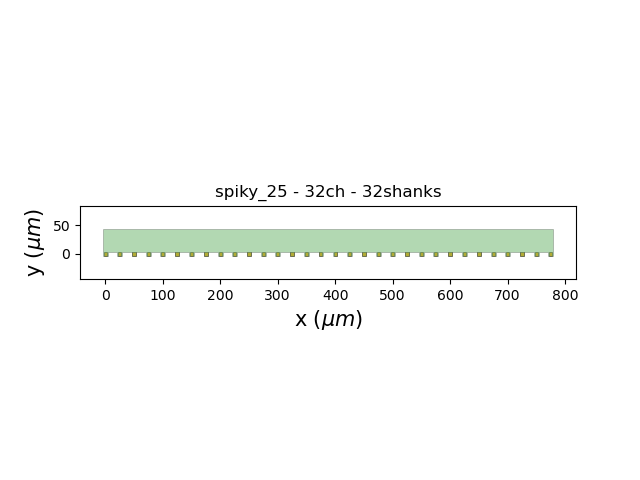

In [8]:
probe_group = pi.io.read_probeinterface("/Volumes/AFedor_T7/TTK-NeuroData/spiky_25.json")
spiky_25 = probe_group.probes[0]
plot_probe(spiky_25)

In [9]:
recording = recording.set_probe(spiky_25)
print(recording.get_probe())

spiky_25 - 32ch - 32shanks


## Sorting Object
from the KiloSorted and manually curated data

In [20]:
# Note that you can change the folder to be loaded by changing the index of the dictionary
# Should be the same as the one used for loading the recording!!!
phy_folder = data_folders["SP9_01"]
sorting = read_phy(phy_folder)
print(sorting)

PhySortingExtractor: 35 units - 1 segments - 20.0kHz


## SortingAnalyzer Object

### Preprocessing the Recording

In [11]:
rec_f = pre.bandpass_filter(recording, freq_min=300., freq_max=6000.)
rec_cmr = pre.common_reference(rec_f, reference='global', operator='median')

### Temporary SortingAnalyzer for fixing peak shift

In [12]:
peak_channel = 'both' # 'neg', 'pos', or 'both'

tmp_sorting_analyzer = create_sorting_analyzer(sorting=sorting, recording=rec_cmr, peak_sign=peak_channel)
tmp_sorting_analyzer.compute("random_spikes", max_spikes_per_unit=5000)
tmp_sorting_analyzer.compute("waveforms", ms_before=1.3, ms_after=2.6, n_jobs=4)
tmp_sorting_analyzer.compute("templates", operators=["average", "median", "std"], n_jobs=4)

unit_peak_shifts = si.get_template_extremum_channel_peak_shift(
    tmp_sorting_analyzer,
    peak_sign="both"
)

#aligned_sorting = align_sorting(sorting_good, unit_peak_shifts) # this shifts 2x to the wrong direction
aligned_sorting_reverse = post.align_sorting(sorting, {key: -value for key, value in unit_peak_shifts.items()}) #this one works

estimate_sparsity (no parallelization):   0%|          | 0/180 [00:00<?, ?it/s]

create_sorting_analyzer: recording does not have scaling to uV, forcing return_in_uV=False


compute_waveforms (workers: 4 processes spawn):   0%|          | 0/180 [00:00<?, ?it/s]

### The SortingAnalyzer

In [14]:
sa_folder = data_folders["SP9_01"] + "/sorting_analyzer"

sorting_analyzer = create_sorting_analyzer(
    sorting=aligned_sorting_reverse, 
    recording=rec_cmr, 
    format="binary_folder", 
    folder=sa_folder, 
    peak_sign=peak_channel, 
    overwrite=True
    )

# for easier and faster computing, we compute all the features in one go 
# using a dictionary with the feature names and their parameters
job_kwargs = dict(n_jobs=4, chunk_duration="1s", progress_bar=True)
compute_dict = {
    'random_spikes': {'max_spikes_per_unit': 5000},
    'waveforms': {'ms_before': 1.3, 'ms_after': 2.6},
    'templates': {'operators': ["average", "median", "std"]},
    'spike_amplitudes': {'peak_sign': peak_channel},
    'amplitude_scalings': {},
    'spike_locations': {'ms_before': 0.5, 'ms_after': 0.5, 'method': "center_of_mass", 'spike_retriever_kwargs': dict(peak_sign=peak_channel)},
    'template_similarity': {'method': 'cosine_similarity'},
    'unit_locations': {'method': "monopolar_triangulation"},
    'noise_levels': {},
    'principal_components': {'n_components': 3, 'mode': "by_channel_local"},
    'isi_histograms': {},
    'correlograms': {'window_ms': 30, 'bin_ms': 1.},
    'quality_metrics': {'metric_names': ["snr", "firing_rate"]}
}
sorting_analyzer.compute(compute_dict, **job_kwargs)

estimate_sparsity (no parallelization):   0%|          | 0/180 [00:00<?, ?it/s]

create_sorting_analyzer: recording does not have scaling to uV, forcing return_in_uV=False


compute_waveforms (workers: 4 processes spawn):   0%|          | 0/180 [00:00<?, ?it/s]

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/opt/anaconda3/envs/si_env/lib/python3.11/site-packages/spikeinterface/postprocessing/template_similarity.py:345: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  overlapping_ids = overlapping_j_list[i]


noise_level (workers: 4 processes spawn):   0%|          | 0/20 [00:00<?, ?it/s]

Fitting PCA:   0%|          | 0/35 [00:00<?, ?it/s]

Projecting waveforms:   0%|          | 0/35 [00:00<?, ?it/s]

Compute : spike_amplitudes + amplitude_scalings + spike_locations (workers: 4 processes spawn):   0%|         …

In [15]:
print(sorting_analyzer)

SortingAnalyzer: 32 channels - 35 units - 1 segments - binary_folder - sparse - has recording
Loaded 13 extensions: random_spikes, waveforms, templates, template_similarity, unit_locations, noise_levels, principal_components, isi_histograms, correlograms, quality_metrics, spike_amplitudes, amplitude_scalings, spike_locations


### Analyzing Waveforms and Templates

In [16]:
# Waveforms
ext_wf = sorting_analyzer.get_extension("waveforms")
print("Names of columns in the waveforms table:")
print("unit_ids: (num_spikes, num_sample, num_channel)")
for unit_id in sorting_analyzer.unit_ids:
    wfs = ext_wf.get_waveforms_one_unit(unit_id)
    print(unit_id, ":", wfs.shape)

print("-" * 50)

# Templates
ext_templates = sorting_analyzer.get_extension("templates")

print("Names of columns in the templates table:")
print("(num_units, num_sample, num_channel)")
av_templates = ext_templates.get_data(operator="average")
print("average templates shape:")
print(av_templates.shape)
print()
median_templates = ext_templates.get_data(operator="median")
print("median templates shape:")
print(median_templates.shape)

Names of columns in the waveforms table:
unit_ids: (num_spikes, num_sample, num_channel)
0 : (2, 78, 6)
1 : (18, 78, 6)
2 : (40, 78, 6)
3 : (18, 78, 6)
4 : (41, 78, 9)
5 : (73, 78, 6)
6 : (8, 78, 9)
7 : (5, 78, 9)
8 : (13, 78, 9)
9 : (4, 78, 9)
10 : (5, 78, 9)
11 : (618, 78, 9)
14 : (25, 78, 9)
15 : (6, 78, 9)
16 : (5, 78, 9)
17 : (26, 78, 9)
18 : (9, 78, 9)
19 : (3, 78, 9)
20 : (2970, 78, 9)
21 : (6, 78, 9)
22 : (6, 78, 9)
24 : (200, 78, 9)
25 : (70, 78, 9)
26 : (4, 78, 9)
29 : (7, 78, 9)
30 : (535, 78, 9)
31 : (5, 78, 9)
32 : (13, 78, 9)
70 : (8, 78, 9)
71 : (124, 78, 9)
72 : (5, 78, 9)
73 : (93, 78, 9)
124 : (26, 78, 9)
133 : (836, 78, 9)
136 : (9, 78, 9)
--------------------------------------------------
Names of columns in the templates table:
(num_units, num_sample, num_channel)
average templates shape:
(35, 78, 32)

median templates shape:
(35, 78, 32)


In [ ]:
# plotting a few templates of selected units that have a high spike count
units_to_plot = list([11, 20, 30, 71, 133])
idx_of_unit_to_plot = [i for i, v in enumerate(sorting_analyzer.unit_ids) if v in units_to_plot]
for unit_index, unit_id in enumerate(sorting_analyzer.unit_ids[idx_of_unit_to_plot]):
    fig, ax = plt.subplots()
    template = av_templates[unit_index]
    ax.plot(template)
    ax.set_title(f"{unit_id}")
    plt.show()

### Regarding good units with the highest spike count

In [ ]:
# under construction

## Using the SpikeInterface GUI for visualization

this is not a necessity

it doesn't have to be done here

can be done using command line tools while being in the directory of the SortingAnalyzer saved on disk

In [ ]:
# IMPORTANT: gain_to_uV and offset_to_uV values are required for this part!
# gain_to_uV = # this can be found in the .rhd or .rhs files of the recording if Intan, is 0.195 for Open Ephys and 2.34375 for SpikeGLX
# offset_to_uV = # this can likely be found in the params.py file in the KiloSort folder

# note that the directory should be the same as the one used for loading the recording and sorting
# since the sorting_analyzer is already saved in the directory, we can just load it instead of creating it again
sorting_analyzer = load_sorting_analyzer(data_folders["SP9_01"] + "/sorting_analyzer")
sw.plot_sorting_summary(sorting_analyzer, backend="spikeinterface_gui")